# 01 — Data Cleaning & Panel Construction

**Goal:** Load all raw CSVs, audit quality, clean and merge into a unified
panel dataset (`panel.csv`) ready for all downstream analyses.

**Data files** (`../data/parsed/`):
| File | Description |
|---|---|
| `matieres.csv` | Subject metadata — id_mat, nom_mat, module, semestre |
| `notes.csv` | Per-student per-subject grades — mg_mat, mg_module |
| `parcours.csv` | Semester/annual averages, rank, passage (100 students) |
| `profils_anonymes.csv` | Demographics — Genre, origine, Bac, Licence |
| `mapping_id_noms.csv` | Identity bridge — id_anon ↔ Nom/Prénom |



## 1. Imports & Config



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats

DATA_DIR = Path("../data/parsed")
OUT_DIR  = Path("../data/clean")
OUT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)
sns.set_theme(style="whitegrid", palette="muted")


## 2. Load Raw Files



In [2]:
matieres = pd.read_csv(DATA_DIR / "matieres.csv")
notes    = pd.read_csv(DATA_DIR / "notes.csv")
parcours = pd.read_csv(DATA_DIR / "parcours.csv")
profils  = pd.read_csv(DATA_DIR / "profils_anonymes.csv")
mapping  = pd.read_csv(DATA_DIR / "mapping_id_noms.csv")

for name, df in [("matieres", matieres), ("notes", notes), ("parcours", parcours),
                 ("profils", profils), ("mapping", mapping)]:
    print(f"  {name:12s}: {df.shape[0]:4d} rows x {df.shape[1]} cols")


  matieres    :   26 rows x 4 cols
  notes       : 2600 rows x 5 cols
  parcours    :  100 rows x 7 cols
  profils     :  143 rows x 6 cols
  mapping     :  143 rows x 4 cols


## 3. Per-Table Audit



In [3]:
def audit(df, name):
    print(f"\n{'='*55}\n  {name.upper()}\n{'='*55}")
    miss = df.isnull().sum()
    print(f"  Duplicates   : {df.duplicated().sum()}")
    if miss.any():
        print(f"  Missing:\n{miss[miss > 0]}")
    else:
        print("  Missing      : none")
    print(f"\n{df.dtypes}\n")
    print(df.head(3))

for name, df in [("matieres", matieres), ("notes", notes), ("parcours", parcours),
                 ("profils", profils), ("mapping", mapping)]:
    audit(df, name)



  MATIERES
  Duplicates   : 0
  Missing      : none

id_mat        str
nom_mat       str
nom_module    str
semestre      str
dtype: object

  id_mat            nom_mat       nom_module semestre
0    i01          algo.num1  Mathématiques 5       S1
1    i02  opt prog lineaire  Mathématiques 5       S1
2    i03        prog java 2  Développement 5       S1

  NOTES
  Duplicates   : 0
  Missing:
mg_module    204
dtype: int64

id               str
promo          int64
id_mat           str
mg_mat       float64
mg_module    float64
dtype: object

           id  promo id_mat  mg_mat  mg_module
0  02d62872c6      2    i01   16.50      17.60
1  02d62872c6      2    i02   18.70      17.60
2  02d62872c6      2    i03   12.60      13.76

  PARCOURS
  Duplicates   : 0
  Missing      : none

id             str
promo        int64
moy_s1     float64
moy_s2     float64
moy_ann    float64
rang       float64
passage        str
dtype: object

           id  promo  moy_s1  moy_s2  moy_ann  rang passage
0  

## 4. Clean Each Table



In [4]:
# ── matieres ──────────────────────────────────────────────────────────────────
matieres.columns = matieres.columns.str.strip().str.lower()
matieres["id_mat"]     = matieres["id_mat"].str.strip()
matieres["nom_mat"]    = matieres["nom_mat"].str.strip()
matieres["nom_module"] = matieres["nom_module"].str.strip()
matieres["semestre"]   = matieres["semestre"].str.upper().str.strip()

# ── notes ──────────────────────────────────────────────────────────────────────
notes.columns = notes.columns.str.strip().str.lower()
notes["id"]     = notes["id"].str.strip()
notes["id_mat"] = notes["id_mat"].str.strip()
for col in ["mg_mat", "mg_module"]:
    bad = notes[~notes[col].between(0, 20)]
    if len(bad):
        print(f"WARNING: {len(bad)} out-of-range rows in notes.{col}")
        print(bad)
    notes[col] = notes[col].clip(0, 20)

# ── parcours ───────────────────────────────────────────────────────────────────
parcours.columns = parcours.columns.str.strip().str.lower()
parcours["id"]      = parcours["id"].str.strip()
parcours["passage"] = parcours["passage"].str.strip()
for col in ["moy_s1", "moy_s2", "moy_ann"]:
    parcours[col] = parcours[col].clip(0, 20)
parcours["rang"] = parcours["rang"].astype("Int64")

# ── profils ────────────────────────────────────────────────────────────────────
profils.columns = (profils.columns.str.strip().str.lower()
                           .str.replace(r"[\s/]+", "_", regex=True))
# Rename ambiguous column — adapt if your CSV uses a different header
rename_map = {c: "licence" for c in profils.columns if "licence" in c or "pisi" in c}
if rename_map:
    profils = profils.rename(columns=rename_map)
profils["id_anon"] = profils["id_anon"].str.strip()
for c in ["genre", "origine", "licence", "bac"]:
    if c in profils.columns:
        profils[c] = profils[c].str.lower().str.strip()

# ── mapping ────────────────────────────────────────────────────────────────────
mapping.columns = mapping.columns.str.strip()
mapping = mapping.rename(columns={c: c.lower() for c in mapping.columns
                                  if c.lower() in ["promotion"]})
mapping["id_anon"] = mapping["id_anon"].str.strip()
mapping["Nom"]     = mapping["Nom"].str.upper().str.strip()
mapping["Prénom"]  = mapping["Prénom"].str.title().str.strip()

print("\nAll tables cleaned.")


              id  promo id_mat  mg_mat  mg_module
23    02d62872c6      2    i24   16.75        NaN
24    02d62872c6      2    i25   15.50        NaN
25    02d62872c6      2    i26   12.25        NaN
49    033574f04c      2    i24   17.25        NaN
50    033574f04c      2    i25   14.50        NaN
...          ...    ...    ...     ...        ...
2494  f39b607f46      2    i25   15.50        NaN
2495  f39b607f46      2    i26   13.50        NaN
2519  f6c4c529c5      2    i24   15.00        NaN
2520  f6c4c529c5      2    i25   14.00        NaN
2521  f6c4c529c5      2    i26   12.50        NaN

[204 rows x 5 columns]

All tables cleaned.


## 5. ID Reconciliation

`parcours.id` / `notes.id` are the primary anonymous IDs.
`profils.id_anon` and `mapping.id_anon` may share the same space.



In [5]:
parc_ids = set(parcours["id"])
prof_ids = set(profils["id_anon"])
map_ids  = set(mapping["id_anon"])

print(f"parcours ids        : {len(parc_ids)}")
print(f"profils  ids        : {len(prof_ids)}")
print(f"mapping  ids        : {len(map_ids)}")
print(f"parcours ^ profils  : {len(parc_ids & prof_ids)}")
print(f"parcours ^ mapping  : {len(parc_ids & map_ids)}")
# Interpret:
#   == full set  -> direct join on id / id_anon
#   == 0         -> different ID spaces, need a bridge


parcours ids        : 100
profils  ids        : 143
mapping  ids        : 143
parcours ^ profils  : 100
parcours ^ mapping  : 100


## 6. Build the Panel Dataset

Join strategy:
  parcours (anchor)
    LEFT JOIN profils  ON id = id_anon   [demographics]
    LEFT JOIN mapping  ON id = id_anon   [names]
    LEFT JOIN notes_wide ON id + promo   [subject grades pivoted wide]
    LEFT JOIN module_avg ON id + promo   [module averages pivoted wide]



In [6]:
# ── 6a. Wide grades: pivot notes so each subject is a column ──────────────────
notes_wide = (
    notes
    .merge(matieres[["id_mat", "nom_mat"]], on="id_mat", how="left")
    .pivot_table(index=["id", "promo"], columns="nom_mat",
                 values="mg_mat", aggfunc="mean")
    .reset_index()
)
notes_wide.columns.name = None
grade_cols = [c for c in notes_wide.columns if c not in ["id", "promo"]]
print(f"Subject columns: {grade_cols}")

# ── 6b. Module averages wide ──────────────────────────────────────────────────
module_avg = (
    notes
    .merge(matieres[["id_mat", "nom_module"]], on="id_mat", how="left")
    .groupby(["id", "promo", "nom_module"])["mg_module"].mean()
    .reset_index()
    .pivot_table(index=["id", "promo"], columns="nom_module",
                 values="mg_module", aggfunc="mean")
    .reset_index()
)
module_avg.columns.name = None
module_avg.columns = (["id", "promo"] +
                      [f"mod_{c}" for c in module_avg.columns[2:]])

# ── 6c. Join demographics ─────────────────────────────────────────────────────
panel = parcours.copy()
direct_overlap = len(parc_ids & prof_ids) / len(parc_ids)

if direct_overlap > 0.5:
    panel = panel.merge(profils.rename(columns={"id_anon": "id"}),
                        on="id", how="left")
    print(f"Joined profils (direct id match): "
          f"{panel['genre'].notna().sum()}/{len(panel)} matched")
else:
    # Try via mapping as bridge: mapping has id_anon + Promotion
    # Profils uses the same id_anon space as mapping
    print("Direct ID overlap low — check if parcours.promo aligns with mapping.Promotion")
    # Attempt join via promo + rank as approximate bridge (last resort)
    panel = panel.merge(profils.rename(columns={"id_anon": "id"}),
                        on="id", how="left")

# ── 6d. Join grades ───────────────────────────────────────────────────────────
panel = panel.merge(notes_wide,  on=["id", "promo"], how="left")
panel = panel.merge(module_avg,  on=["id", "promo"], how="left")

print(f"\nPanel shape: {panel.shape}")
print(panel.head(3))


Subject columns: ['Devp mob', 'TOEIC3', 'TOEIC4', 'agile', 'algo num2', 'algo.num1', 'appr auto', "ches de mkv-fil d'at", 'cloud comp', 'devops1', 'dt des entpses', 'ent de données', "fond de l'IA", 'gest des ress hum', 'init au big data', 'mod UML/OCL', 'opt prog lineaire', 'opt&prog nn lin', 'prog java 2', 'prog log', 'sem et proj', 'tech sem', 'test log', 'théo de l inf cod cr', 'virtualisation', 'vtes ind']
Joined profils (direct id match): 100/100 matched

Panel shape: (100, 46)
           id  promo  moy_s1  moy_s2  moy_ann  rang passage  promotion genre  \
0  02d62872c6      2   15.22   15.84    15.53     2   Admis          2     m   
1  033574f04c      2   13.52   14.52    14.02     8   Admis          2     m   
2  033b92fdb6      3   11.97   12.56    12.27    22   Admis          3     m   

  origine licence   bac  Devp mob  TOEIC3  TOEIC4  agile  algo num2  \
0    sfax    pisi  math     17.11   16.00   16.75  13.79      16.10   
1    sfax    pisi  math     18.64   11.75   17.2

## 7. Derived Features



In [7]:
panel["delta_s2_s1"]     = panel["moy_s2"] - panel["moy_s1"]
panel["passage_bin"]     = (panel["passage"] == "Admis").astype(int)
panel["top_quartile"]    = (panel["moy_ann"] >= panel["moy_ann"].quantile(0.75)).astype(int)
panel["bottom_quartile"] = (panel["moy_ann"] <= panel["moy_ann"].quantile(0.25)).astype(int)

# Rank normalised within promo: 1 = best in promo
panel["rang_norm"] = panel.groupby("promo")["rang"].transform(
    lambda x: 1 - (x - x.min()) / (x.max() - x.min() + 1e-9)
)

print("Derived columns added:")
print(panel[["id", "promo", "moy_ann", "delta_s2_s1",
             "passage_bin", "rang_norm"]].head(5))


Derived columns added:
           id  promo  moy_ann  delta_s2_s1  passage_bin  rang_norm
0  02d62872c6      2    15.53         0.62            1       0.97
1  033574f04c      2    14.02         1.00            1       0.80
2  033b92fdb6      3    12.27         0.59            1       0.32
3  06ab8aee6d      3    12.63         0.08            1       0.48
4  0af7383ac5      3    12.56         1.53            1       0.35


## 8. Missing Values & Imputation



Columns with missing values:
         count  pct
bac          6 6.00
origine      1 1.00


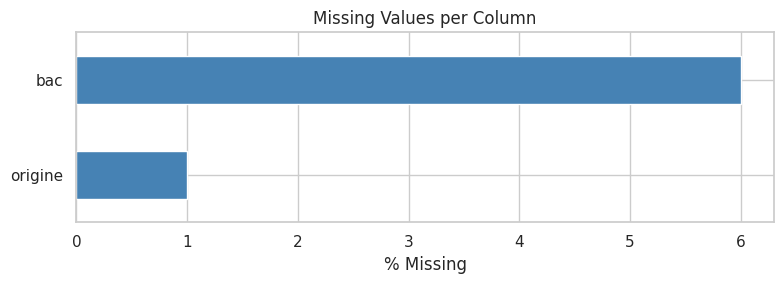

Grade NAs imputed with promo median.


In [8]:
miss = panel.isnull().sum()
miss_pct = (miss / len(panel) * 100).round(1)
miss_report = pd.DataFrame({"count": miss, "pct": miss_pct})
miss_report = miss_report[miss_report["count"] > 0].sort_values("count", ascending=False)

if len(miss_report):
    print("Columns with missing values:")
    print(miss_report)

    fig, ax = plt.subplots(figsize=(8, max(3, len(miss_report) * 0.45)))
    miss_report["pct"].sort_values().plot.barh(ax=ax, color="steelblue")
    ax.set_xlabel("% Missing")
    ax.set_title("Missing Values per Column")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "missing_values.png", dpi=150)
    plt.show()

    # Impute grade cols with promo-level median
    for col in grade_cols:
        if col in panel.columns and panel[col].isnull().any():
            panel[col] = panel.groupby("promo")[col].transform(
                lambda x: x.fillna(x.median())
            )
    print("Grade NAs imputed with promo median.")
else:
    print("No missing values in panel.")


## 9. Outlier Detection



In [9]:
num_cols = ["moy_s1", "moy_s2", "moy_ann"] + [c for c in grade_cols if c in panel.columns]
z = panel[num_cols].apply(lambda col: np.abs(stats.zscore(col, nan_policy="omit")))
outlier_mask = (z > 3).any(axis=1)
print(f"Students with Z > 3 on any metric: {outlier_mask.sum()}")
if outlier_mask.any():
    print(panel[outlier_mask][["id", "promo", "moy_s1", "moy_s2", "moy_ann"]])

# Mark outliers — do NOT drop; flag for analysis
panel["is_outlier"] = outlier_mask.astype(int)


Students with Z > 3 on any metric: 5
            id  promo  moy_s1  moy_s2  moy_ann
16  2a4ecb964b      2    9.84   11.45    10.65
19  38b2492009      1    9.06   10.15     9.61
66  b43ea83ec0      1   11.40   11.37    11.39
71  bf583166a0      2   11.67   10.60    11.14
73  c31f087a4d      1    7.71    4.09     5.90


## 10. Export Clean Panel



In [10]:
panel.to_csv(OUT_DIR / "panel.csv", index=False)
matieres.to_csv(OUT_DIR / "matieres_clean.csv", index=False)
notes.to_csv(OUT_DIR / "notes_clean.csv", index=False)

print(f"Saved: panel.csv  [{panel.shape[0]} rows x {panel.shape[1]} cols]")
print(f"Columns: {list(panel.columns)}")


Saved: panel.csv  [100 rows x 52 cols]
Columns: ['id', 'promo', 'moy_s1', 'moy_s2', 'moy_ann', 'rang', 'passage', 'promotion', 'genre', 'origine', 'licence', 'bac', 'Devp mob', 'TOEIC3', 'TOEIC4', 'agile', 'algo num2', 'algo.num1', 'appr auto', "ches de mkv-fil d'at", 'cloud comp', 'devops1', 'dt des entpses', 'ent de données', "fond de l'IA", 'gest des ress hum', 'init au big data', 'mod UML/OCL', 'opt prog lineaire', 'opt&prog nn lin', 'prog java 2', 'prog log', 'sem et proj', 'tech sem', 'test log', 'théo de l inf cod cr', 'virtualisation', 'vtes ind', 'mod_Big Data & Cloud', 'mod_Développement 5', 'mod_IA & Virtualisation', 'mod_ML, DevOp & dev mobile', 'mod_Mathématiques 5', 'mod_Mathématiques 6', 'mod_Sémantique & Sys distribué', 'mod_Th info, entrepot & IHM', 'delta_s2_s1', 'passage_bin', 'top_quartile', 'bottom_quartile', 'rang_norm', 'is_outlier']


## 11. Sanity Check



In [11]:
print("\n── Promo distribution ──")
print(panel["promo"].value_counts().sort_index())
print("\n── Passage rate ──")
print((panel["passage"].value_counts(normalize=True) * 100).round(1))
print("\n── Mean annual avg by promo ──")
print(panel.groupby("promo")["moy_ann"].agg(["mean", "std", "min", "max"]).round(2))



── Promo distribution ──
promo
1    32
2    36
3    32
Name: count, dtype: int64

── Passage rate ──
passage
Admis        84.00
Rattrapage   16.00
Name: proportion, dtype: float64

── Mean annual avg by promo ──
       mean  std   min   max
promo                       
1     12.27 1.82  5.90 15.93
2     12.56 1.54  9.34 15.62
3     12.91 1.31 10.62 15.89
